<a href="https://colab.research.google.com/github/welmi496/Introduction-to-Artificial-Intelligence/blob/main/Assignment14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Assignment 14: Ethical AI Analysis and Explainability

## Dataset: Adult Census Income Dataset

**Objective:** Train a logistic regression model, evaluate predictive performance, assess fairness using Fairlearn, and explain predictions using SHAP and LIME.

**Deliverables covered in this notebook**
- Dataset preparation
- Model training and evaluation
- Fairness analysis
- Explainability analysis
- Visualizations required by the assignment

## Links:

- Colab notebook link: https://colab.research.google.com/drive/1u-JIF2fx0jy4UN4w5lLtBAtz2wzbCSpm?usp=sharing
- GitHub repository link: https://github.com/welmi496/Introduction-to-Artificial-Intelligence/blob/main/Assignment14.ipynb
- GitHub repository README link: https://github.com/welmi496/Introduction-to-Artificial-Intelligence/blob/main/README14.md

## 1. Install and Import Required Libraries

In [ ]:
!pip install -q fairlearn shap lime

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fairlearn.datasets import fetch_adult
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    false_positive_rate,
    true_positive_rate
)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import shap
from lime.lime_tabular import LimeTabularExplainer

## 2. Load Dataset and Identify Sensitive Attribute

In [ ]:
# Load the Adult Census Income dataset
X_raw, y_raw = fetch_adult(as_frame=True, return_X_y=True)

# Convert target to numeric: >50K = 1, <=50K = 0
y = (y_raw == '>50K').astype(int)

# Sensitive attribute for fairness analysis
sensitive_feature = X_raw['sex']

# Quick check
print("Feature shape:", X_raw.shape)
print("Target distribution:")
print(y.value_counts())
print("\nSensitive feature distribution:")
print(sensitive_feature.value_counts())

X_raw.head()

Feature shape: (48842, 14)
Target distribution:
class
0    37155
1    11687
Name: count, dtype: int64

Sensitive feature distribution:
sex
Male      32650
Female    16192
Name: count, dtype: int64


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


## 3. Preprocessing

We use:
- **Target (`y`)**: income above \$50K  
- **Sensitive feature**: `sex`  
- **Numerical preprocessing**: median imputation + standardization  
- **Categorical preprocessing**: most frequent imputation + one-hot encoding  

In [ ]:
# Separate numerical and categorical columns
numeric_features = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()

# Keep the sensitive feature in the input features as part of the real dataset,
# while also storing it separately for fairness evaluation
print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Numeric features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


## 4. Train-Test Split and Logistic Regression Model

In [ ]:
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X_raw, y, sensitive_feature,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Model training completed.")

Model training completed.


## 5. Model Evaluation

Accuracy: 0.8524

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      7431
           1       0.74      0.59      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.85      0.85      0.85      9769



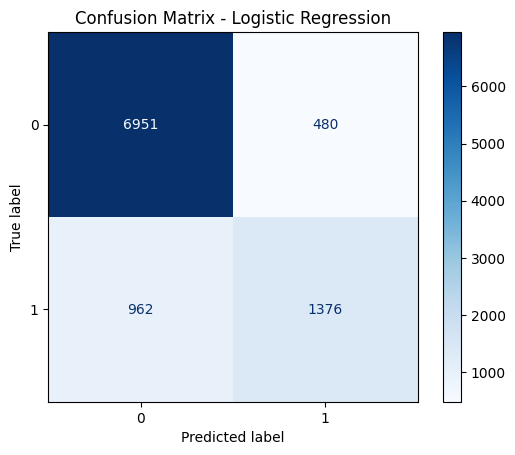

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 6. Fairness Analysis with Fairlearn

We compute:
- Selection Rate
- False Positive Rate
- True Positive Rate

Then we use `MetricFrame` to compare metrics across groups defined by the sensitive attribute.

In [ ]:
metric_frame = MetricFrame(
    metrics={
        'selection_rate': selection_rate,
        'false_positive_rate': false_positive_rate,
        'true_positive_rate': true_positive_rate,
        'accuracy': accuracy_score
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

print("Overall metrics:")
print(metric_frame.overall)

print("\nMetrics by group:")
print(metric_frame.by_group)

Overall metrics:
selection_rate         0.189989
false_positive_rate    0.064594
true_positive_rate     0.588537
accuracy               0.852390
dtype: float64

Metrics by group:
        selection_rate  false_positive_rate  true_positive_rate  accuracy
sex                                                                      
Female        0.075790             0.022084            0.506925  0.925744
Male          0.247158             0.091771            0.603440  0.815668


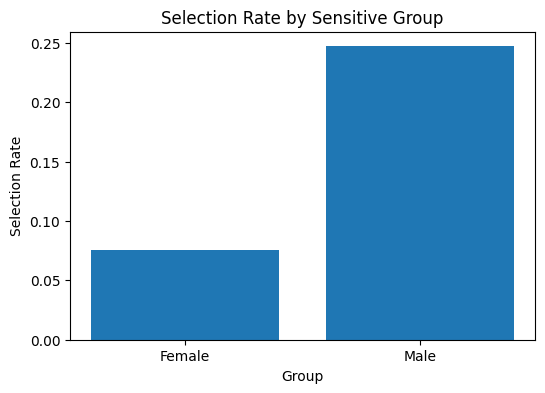

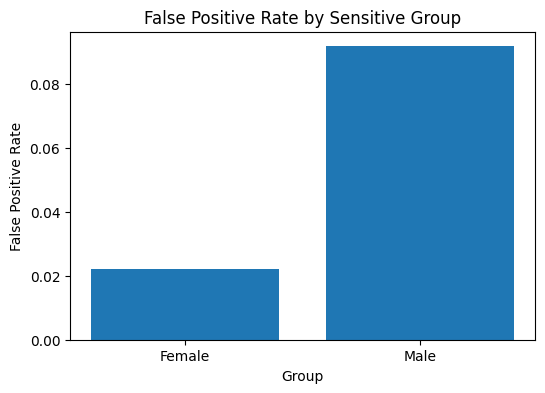

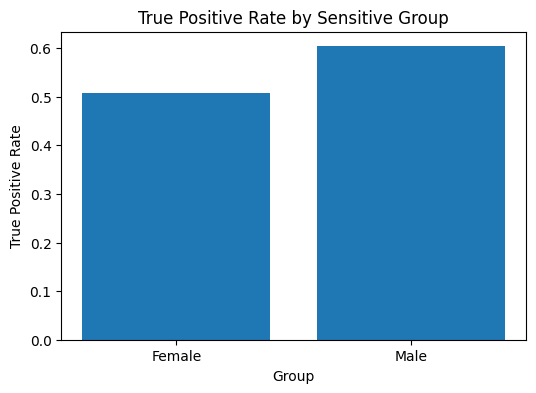

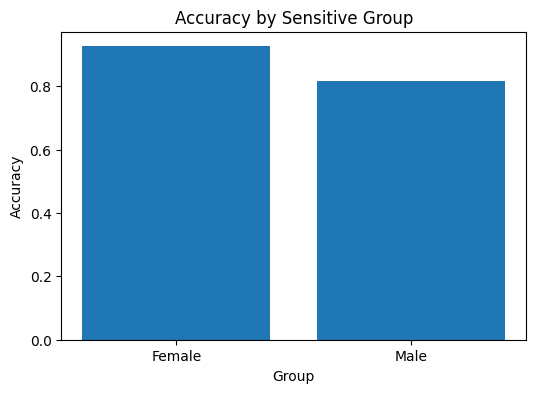

In [ ]:
fairness_df = metric_frame.by_group.reset_index()
fairness_df = fairness_df.rename(columns={'sex': 'group'})

metrics_to_plot = ['selection_rate', 'false_positive_rate', 'true_positive_rate', 'accuracy']

for metric in metrics_to_plot:
    plt.figure(figsize=(6,4))
    plt.bar(fairness_df['group'], fairness_df[metric])
    plt.title(f'{metric.replace("_", " ").title()} by Sensitive Group')
    plt.xlabel('Group')
    plt.ylabel(metric.replace("_", " ").title())
    plt.show()

## 7. SHAP Explainability

We use SHAP on the preprocessed test data to produce:
- A **global** summary plot
- A **local** waterfall plot for one individual prediction

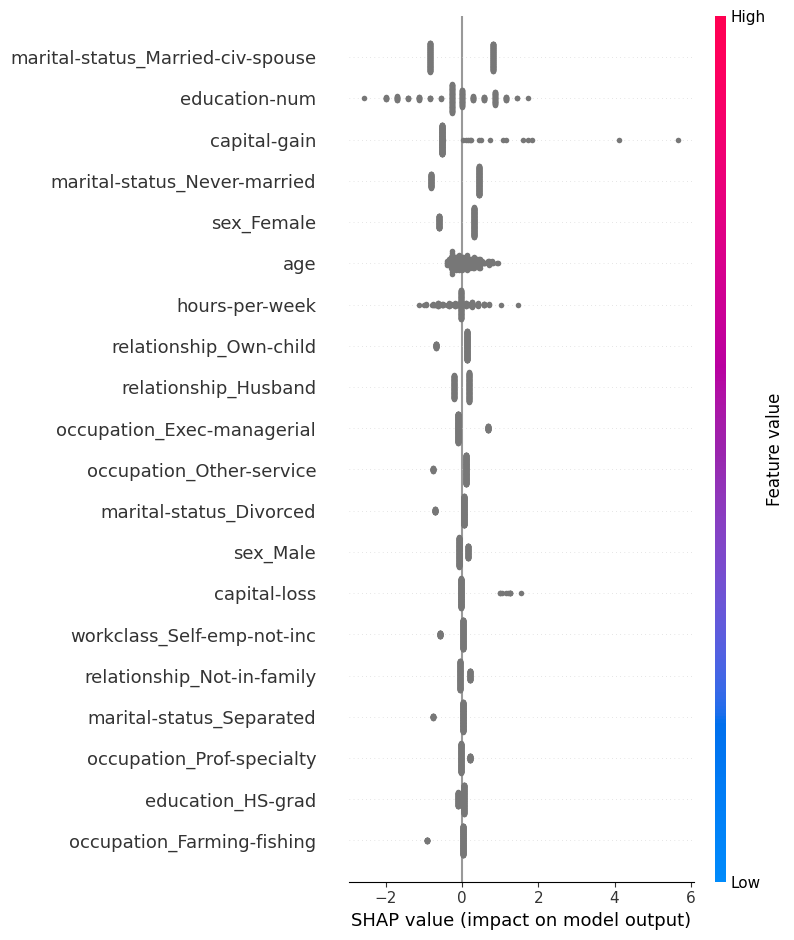

In [ ]:
# Transform the data using the fitted preprocessor
X_train_processed = model.named_steps['preprocessor'].transform(X_train)
X_test_processed = model.named_steps['preprocessor'].transform(X_test)

# Get final feature names after preprocessing
ohe = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_names = ohe.get_feature_names_out(categorical_features)
feature_names = numeric_features + encoded_cat_names.tolist()

# Create SHAP explainer for logistic regression
classifier = model.named_steps['classifier']
explainer = shap.Explainer(classifier, X_train_processed, feature_names=feature_names)
shap_values = explainer(X_test_processed[:200])

# Global explanation
shap.summary_plot(shap_values, X_test_processed[:200], feature_names=feature_names)

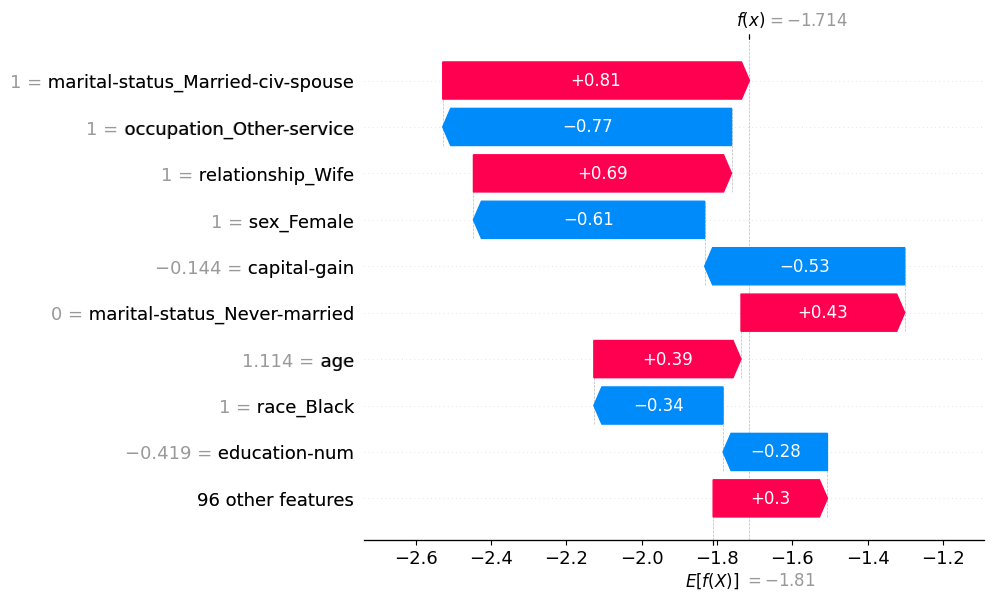

In [ ]:
# Local explanation for one prediction
sample_index = 0
shap.plots.waterfall(shap_values[sample_index], max_display=10)

## 8. LIME Explainability

LIME explains one individual prediction using local surrogate reasoning.

In [ ]:
# Convert sparse matrices to dense arrays for LIME if necessary
if hasattr(X_train_processed, "toarray"):
    X_train_dense = X_train_processed.toarray()
else:
    X_train_dense = X_train_processed

if hasattr(X_test_processed, "toarray"):
    X_test_dense = X_test_processed.toarray()
else:
    X_test_dense = X_test_processed

explainer_lime = LimeTabularExplainer(
    training_data=X_train_dense,
    feature_names=feature_names,
    class_names=['<=50K', '>50K'],
    mode='classification'
)

lime_exp = explainer_lime.explain_instance(
    data_row=X_test_dense[0],
    predict_fn=classifier.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

## 9. Short Interpretation

Use the outputs above to write your final observations in class submission. Keep the discussion focused on:
- how well the model performs,
- whether fairness metrics differ across groups,
- which features are most influential globally,
- and how one individual prediction is explained locally.

## 10. Conclusion

This notebook completed the required tasks:
1. Loaded a public dataset relevant to fairness evaluation  
2. Trained a logistic regression model  
3. Evaluated model performance  
4. Measured fairness across sensitive groups with Fairlearn  
5. Applied SHAP and LIME for explainability  